# PRÁCTICA CALIFICADA GRUPAL N.° 3

## Tema
Expresiones Regulares, Programas en Red y Web Scraping

## Fuente de Datos
TheCatAPI

https://api.thecatapi.com/v1/breeds

La API proporciona información sobre diversas razas de gatos en formato JSON.


In [3]:
# Librerías principales
import requests
import pandas as pd
import re
import matplotlib.pyplot as plt

# Parte I. Programas en Red

Se realizó una conexión HTTP mediante la librería `requests` hacia el endpoint de razas de TheCatAPI.

Se verificó el código de estado HTTP, la URL consultada y el tipo de contenido recibido.

In [4]:
# Parte I - Conexión mediante requests

url = "https://api.thecatapi.com/v1/breeds"

response = requests.get(url)

print("Status Code:", response.status_code)

if response.status_code == 200:
    print("La conexión fue exitosa. El código 200 significa que la solicitud fue procesada correctamente.")
else:
    print("La conexión no fue exitosa. Se obtuvo el código:", response.status_code)

print("URL consultada:", response.url)
print("Content-Type recibido:", response.headers.get("Content-Type"))

Status Code: 200
La conexión fue exitosa. El código 200 significa que la solicitud fue procesada correctamente.
URL consultada: https://api.thecatapi.com/v1/breeds
Content-Type recibido: application/json; charset=utf-8


# Parte II. Recuperación de Datos

Se recuperaron datos desde TheCatAPI en formato JSON.

Para el análisis se utilizaron todas las razas disponibles en la API, superando el mínimo solicitado de 15 registros.

## Atributos extraídos

Se seleccionaron atributos relevantes para comparar características de las razas:

- Nombre de la raza (`name`)
- País de origen (`origin`)
- Esperanza de vida (`life_span`)
- Inteligencia (`intelligence`)
- Adaptabilidad (`adaptability`)
- Nivel de afecto (`affection_level`)

## Uso de Expresiones Regulares

El campo `life_span` viene como texto, por ejemplo: `12 - 15`.

Se usó la expresión regular:

`re.findall(r"\d+", life_span)`

para extraer los números del rango de vida y convertirlos en valores numéricos.

In [5]:
# Parte II - Recuperación de datos

cats = response.json()

print("Total de registros obtenidos:", len(cats))

datos = []

for cat in cats:
    nombre = cat.get("name")
    origen = cat.get("origin")
    life_span = cat.get("life_span")
    inteligencia = cat.get("intelligence")
    adaptabilidad = cat.get("adaptability")
    afecto = cat.get("affection_level")

    # Regex para extraer números de life_span
    numeros = re.findall(r"\d+", life_span)

    if len(numeros) >= 2:
        vida_min = int(numeros[0])
        vida_max = int(numeros[1])
        vida_promedio = (vida_min + vida_max) / 2
    else:
        vida_min = None
        vida_max = None
        vida_promedio = None

    datos.append({
        "Raza": nombre,
        "Origen": origen,
        "Life_Span_Texto": life_span,
        "Vida_Min": vida_min,
        "Vida_Max": vida_max,
        "Vida_Promedio": vida_promedio,
        "Inteligencia": inteligencia,
        "Adaptabilidad": adaptabilidad,
        "Afecto": afecto
    })

print("Registros procesados:", len(datos))

Total de registros obtenidos: 67
Registros procesados: 67


# Parte III. Procesamiento y Análisis

Los datos recuperados fueron organizados en un DataFrame de Pandas.

Se limpió el atributo `life_span` usando expresiones regulares para obtener edad mínima, edad máxima y vida promedio.

Luego se calcularon estadísticas descriptivas sobre inteligencia, adaptabilidad, afecto y esperanza de vida.

In [10]:
# =====================================
# PARTE III - PROCESAMIENTO Y ANÁLISIS
# =====================================

# Verificar que el DataFrame exista
print("Dimensiones del DataFrame original:", df.shape)

# Mostrar las primeras filas
display(df.head())

# Limpieza de datos:
# Se eliminan registros que no tengan valores en las columnas necesarias para el análisis
df_limpio = df.dropna(
    subset=[
        "Vida_Promedio",
        "Inteligencia",
        "Adaptabilidad",
        "Afecto"
    ]
).copy()

print("Registros antes de limpiar:", len(df))
print("Registros después de limpiar:", len(df_limpio))

# Convertir columnas a tipo numérico por seguridad
columnas_numericas = [
    "Vida_Promedio",
    "Inteligencia",
    "Adaptabilidad",
    "Afecto"
]

for columna in columnas_numericas:
    df_limpio[columna] = pd.to_numeric(df_limpio[columna], errors="coerce")

# Mostrar DataFrame limpio
display(df_limpio.head())

# Estadísticas descriptivas principales
estadisticas = df_limpio[columnas_numericas].describe()

display(estadisticas)

# Tres estadísticas descriptivas relevantes
promedio_vida = df_limpio["Vida_Promedio"].mean()
promedio_inteligencia = df_limpio["Inteligencia"].mean()
max_inteligencia = df_limpio["Inteligencia"].max()
min_inteligencia = df_limpio["Inteligencia"].min()

print("Promedio de esperanza de vida:", round(promedio_vida, 2))
print("Promedio de inteligencia:", round(promedio_inteligencia, 2))
print("Máximo nivel de inteligencia:", max_inteligencia)
print("Mínimo nivel de inteligencia:", min_inteligencia)

# Top 5 razas con mayor inteligencia
top5_inteligencia = df_limpio.sort_values(
    by="Inteligencia",
    ascending=False
).head(5)

display(top5_inteligencia[
    [
        "Raza",
        "Origen",
        "Inteligencia",
        "Vida_Promedio",
        "Adaptabilidad",
        "Afecto"
    ]
])

Dimensiones del DataFrame original: (67, 9)


,Raza,Origen,Life_Span_Texto,Vida_Min,Vida_Max,Vida_Promedio,Inteligencia,Adaptabilidad,Afecto
0,Abyssinian,Egypt,14 - 15,14,15,14.5,5,5,5
1,Aegean,Greece,9 - 12,9,12,10.5,3,5,4
2,American Bobtail,United States,11 - 15,11,15,13.0,5,5,5
3,American Curl,United States,12 - 16,12,16,14.0,3,5,5
4,American Shorthair,United States,15 - 17,15,17,16.0,3,5,5


Registros antes de limpiar: 67
Registros después de limpiar: 67


,Raza,Origen,Life_Span_Texto,Vida_Min,Vida_Max,Vida_Promedio,Inteligencia,Adaptabilidad,Afecto
0,Abyssinian,Egypt,14 - 15,14,15,14.5,5,5,5
1,Aegean,Greece,9 - 12,9,12,10.5,3,5,4
2,American Bobtail,United States,11 - 15,11,15,13.0,5,5,5
3,American Curl,United States,12 - 16,12,16,14.0,3,5,5
4,American Shorthair,United States,15 - 17,15,17,16.0,3,5,5


,Vida_Promedio,Inteligencia,Adaptabilidad,Afecto
count,67.000000,67.000000,67.000000,67.000000
mean,13.746269,4.358209,4.820896,4.865672
std,1.584425,0.899520,0.575388,0.422673
min,10.500000,3.000000,2.000000,3.000000
25%,13.000000,3.000000,5.000000,5.000000
50%,13.500000,5.000000,5.000000,5.000000
75%,14.500000,5.000000,5.000000,5.000000
max,19.000000,5.000000,5.000000,5.000000


Promedio de esperanza de vida: 13.75
Promedio de inteligencia: 4.36
Máximo nivel de inteligencia: 5
Mínimo nivel de inteligencia: 3


,Raza,Origen,Inteligencia,Vida_Promedio,Adaptabilidad,Afecto
0,Abyssinian,Egypt,5,14.5,5,5
2,American Bobtail,United States,5,13.0,5,5
9,Bambino,United States,5,13.0,5,5
63,Toyger,United States,5,13.5,5,5
10,Bengal,United States,5,13.5,5,5


## Interpretación de Resultados

Las razas analizadas presentan un nivel de inteligencia promedio relativamente alto, mostrando poca variabilidad entre ellas.

Asimismo, la esperanza de vida promedio indica que la mayoría de las razas incluidas en el análisis poseen una longevidad similar.

# Parte IV. Visualización

Se elaboró un gráfico de barras con las 10 razas con mayor nivel de inteligencia.

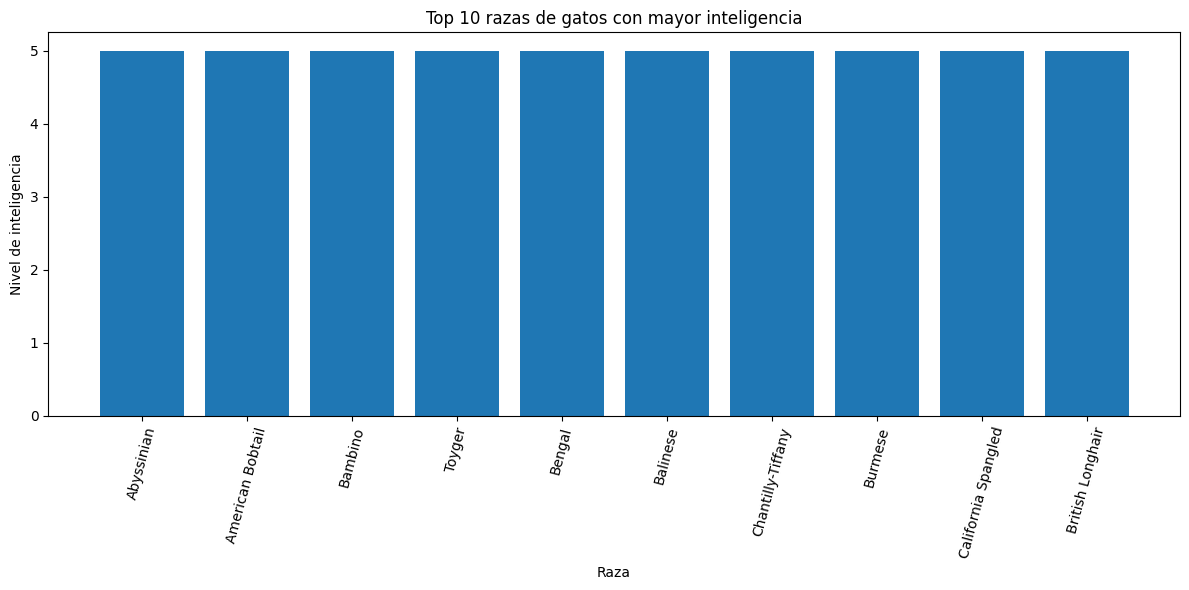

In [11]:
# Parte IV - Visualización

top10 = df_limpio.sort_values(
    by="Inteligencia",
    ascending=False
).head(10)

plt.figure(figsize=(12, 6))
plt.bar(top10["Raza"], top10["Inteligencia"])
plt.title("Top 10 razas de gatos con mayor inteligencia")
plt.xlabel("Raza")
plt.ylabel("Nivel de inteligencia")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

## Interpretación del Gráfico

El gráfico muestra las razas con mayor nivel de inteligencia según los datos proporcionados por TheCatAPI.

Se observa que varias razas alcanzan valores altos, por lo que el gráfico permite identificar rápidamente cuáles destacan frente al resto.

# Parte V. Uso Responsable de IA

## Prompts Utilizados

1. Genera código para obtener 15 registros desde TheCatAPI.
2. Utiliza expresiones regulares para extraer información de life_span.
3. Genera estadísticas descriptivas y gráficos utilizando Pandas y Matplotlib.
4. si tengo que hacer una actividad de websracing: Realice la conexión mediante requests y verifique que la respuesta HTTP sea exitosa. Muestre el status_code y explique su significado. (2 ptos) y con el link https://documenter.getpostman.com/view/5578104/RWgqUxxh, cual seria el codigo en python
5. Que significa el status 200
6. Como obtuviste el enlace a partir del link

## Participación del Grupo

| Integrante | Prompt utilizado | Modificación realizada | Aprendizaje obtenido |
|------------|------------------|-----------------------|---------------------|
| Fernando Ruiz | Conexión API | Ajustó URL y validaciones | Uso de requests |
| Juan Tapia | Recuperación de datos | Selección de atributos | Manejo de JSON |
| Bisitte Becerra| Expresiones regulares | Extracción de life_span | Uso de regex |
| Flavio Vila| Pandas | Limpieza y análisis | DataFrames |
| Alejandra Arroyo  | Visualización | Diseño de gráfico | Matplotlib |